In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# EDA

In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s5e4/train.csv")
df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [3]:
df.isna().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [4]:
df.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [6]:
df = df.drop(columns=["id"])

## Analysis of Numeric Features
The goal of this section is to understand the nature of the numerical features as well as how they relate to one another. This will be useful for feature engineering and feature selection.

In [7]:
num_vars = ["Episode_Length_minutes", "Host_Popularity_percentage", "Guest_Popularity_percentage", 
                "Number_of_Ads", "Listening_Time_minutes"]

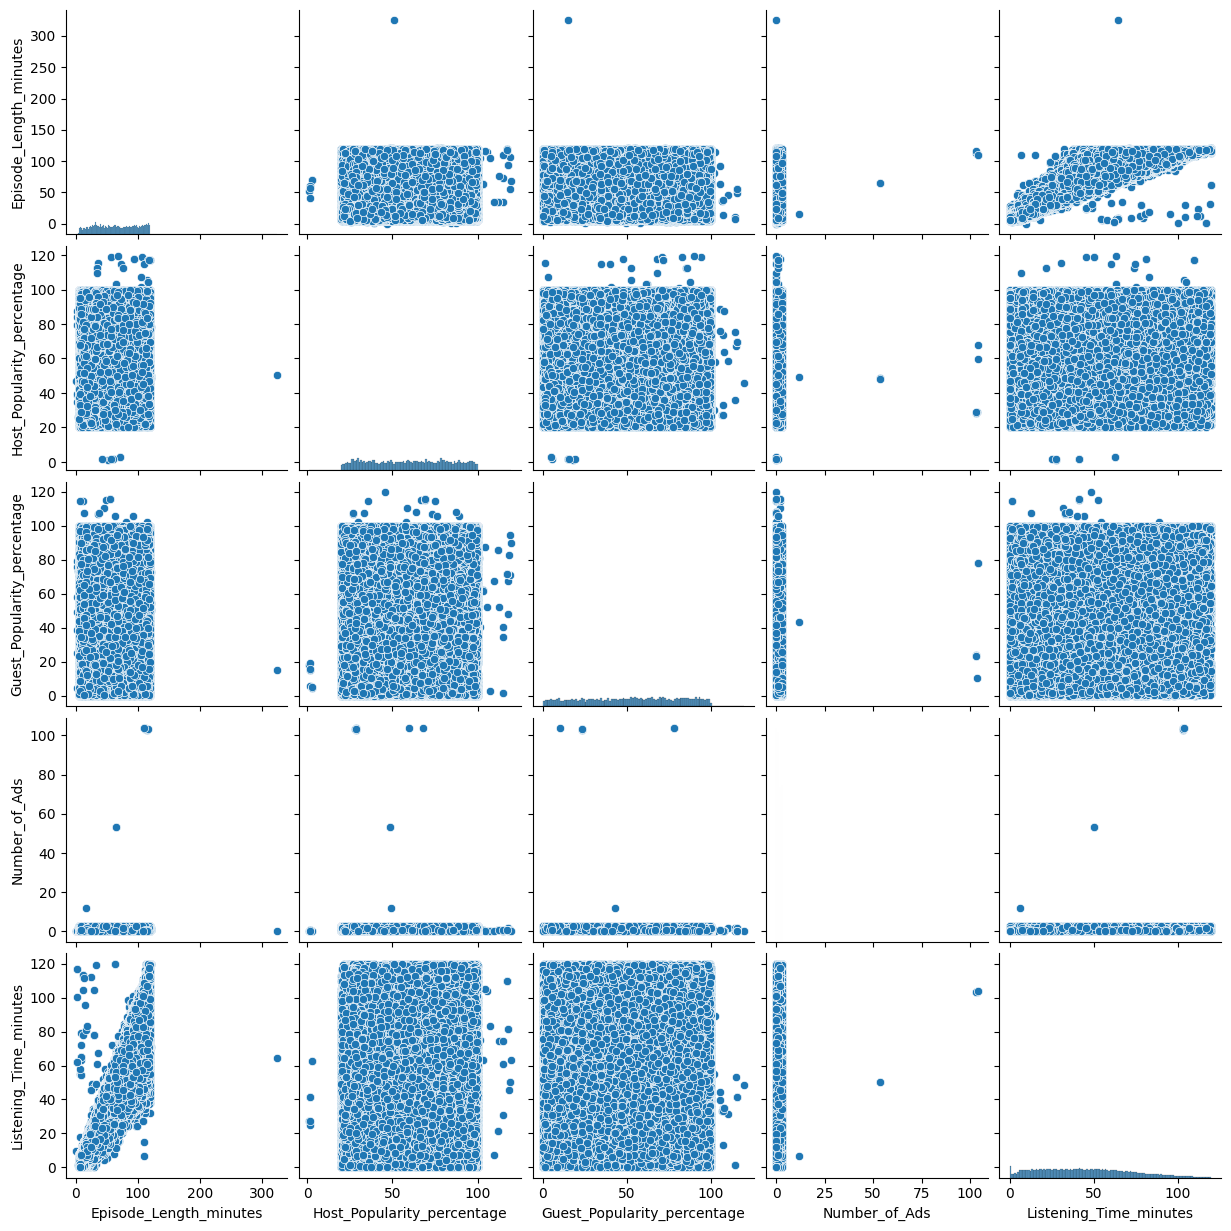

In [8]:
# pairplot
sns.pairplot(df[num_vars])

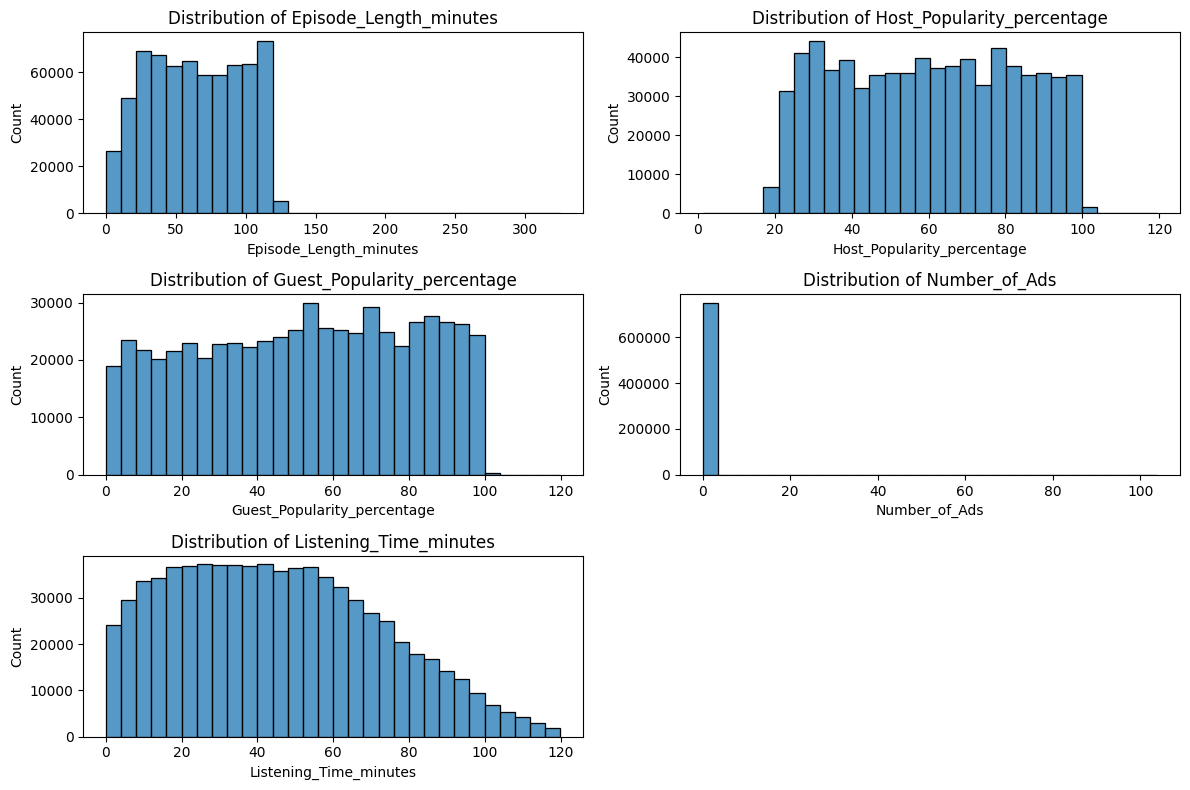

In [9]:
# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.histplot(df[feature], ax=axes[i], bins=30)
    axes[i].set_title(f"Distribution of {feature}")

axes[5].remove()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

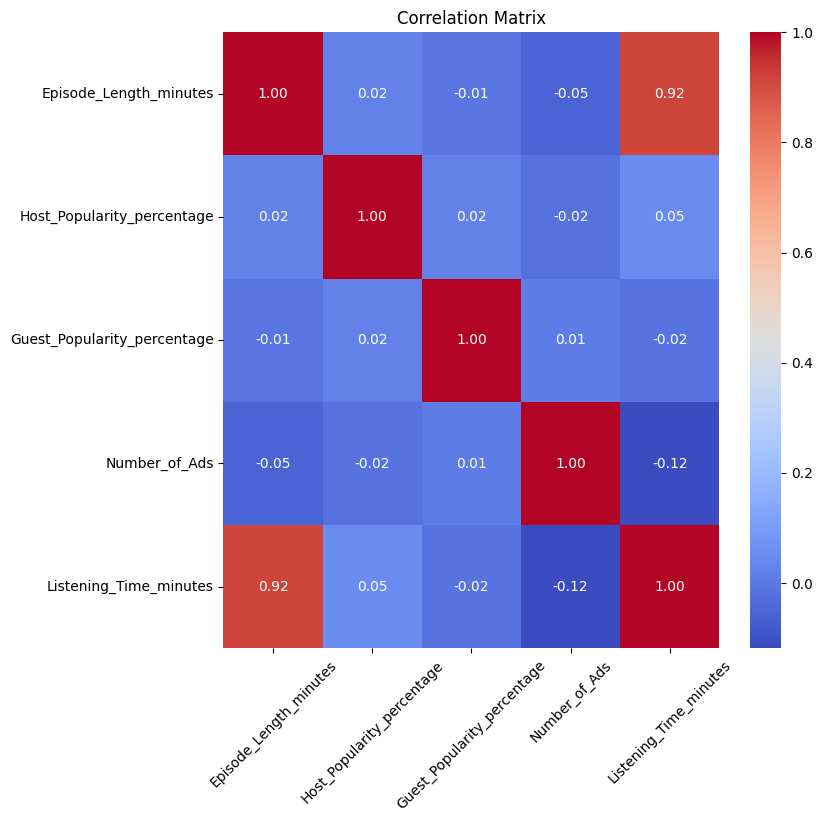

In [10]:
# correlation Matrix
corr_matrix = df[num_vars].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.title("Correlation Matrix")

### Findings from looking at distributions of numeric data  
Data Cleaning
- Need to figure out what to do with outliers
- Need to normalize a lot of the data
- investigate more in detail how each feature relates to the outcome
  
Relationships
- Episode Length very strongly correlated with Listening Time
- Nothing else really relates to listening time potentially because of large amounts of missing values?

## Analysis of Categorical Features

In [11]:
cat_vars = ["Podcast_Name", "Episode_Title", "Genre", "Publication_Day",
               "Publication_Time", "Episode_Sentiment"]

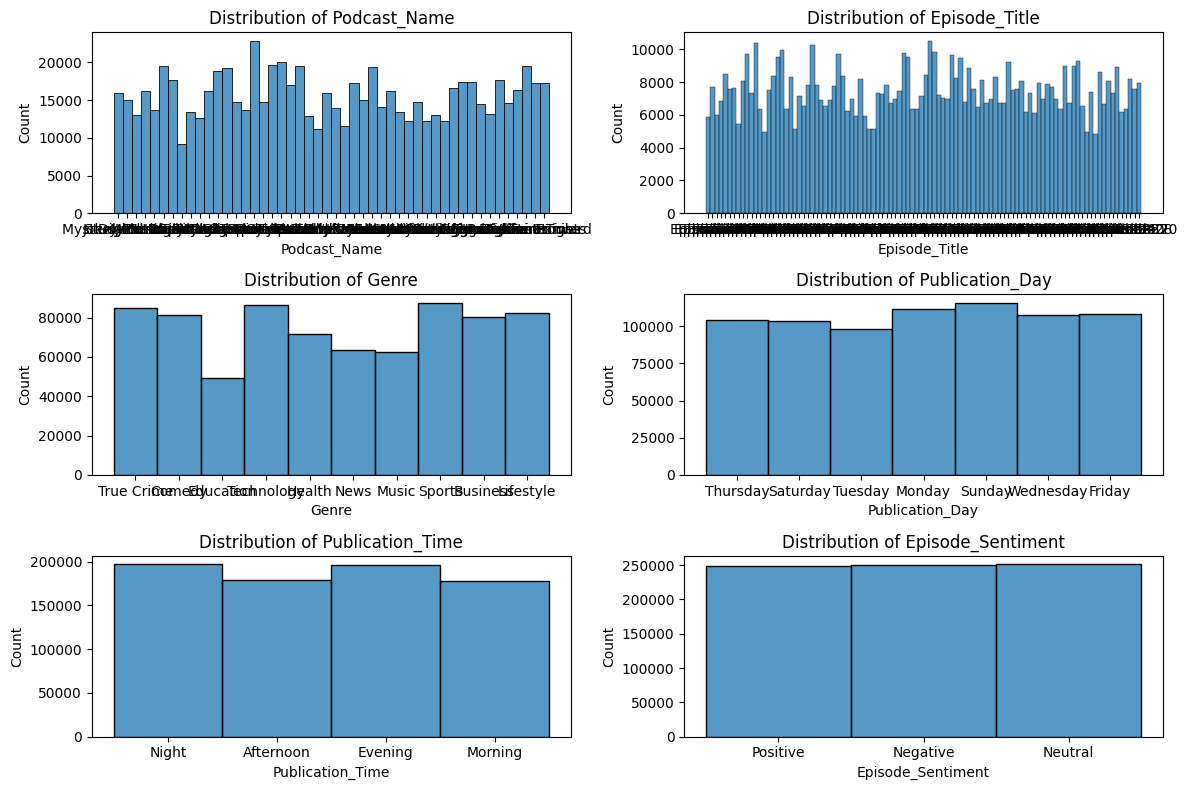

In [12]:
# distributions of categorical features
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.histplot(df[feature], ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

In [13]:
df[cat_vars].nunique()

Podcast_Name          48
Episode_Title        100
Genre                 10
Publication_Day        7
Publication_Time       4
Episode_Sentiment      3
dtype: int64

### Findings from Categorical Data
For most categories, the distribution is fairly balanced. This is really helpful as it makes model more robust due to the high variation in categories.

## Relationships Between Categorical and Numeric Features

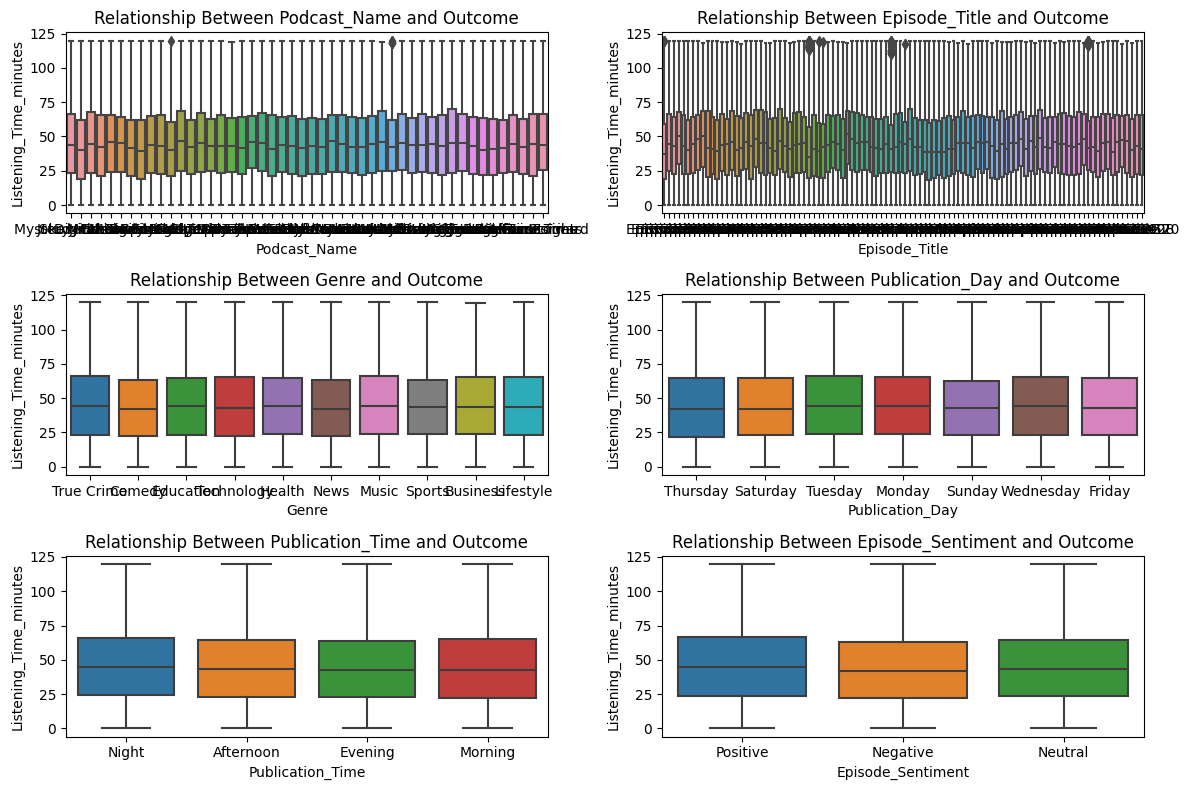

In [14]:
# relationship between cateogircal features and outcome feature
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Listening_Time_minutes"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Outcome")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


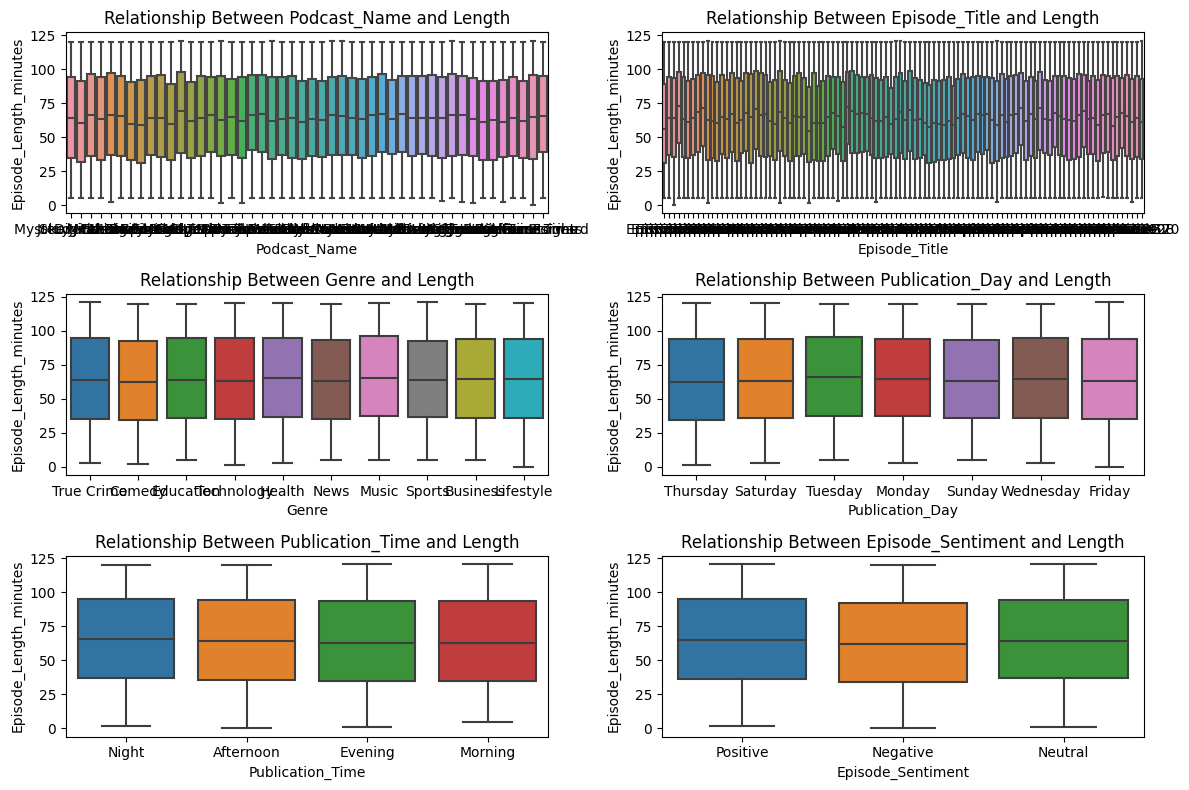

In [15]:
# relationship between cateogircal features and episode length
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df[df["Episode_Length_minutes"] < 300]["Episode_Length_minutes"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Length")

plt.tight_layout()
plt.show()

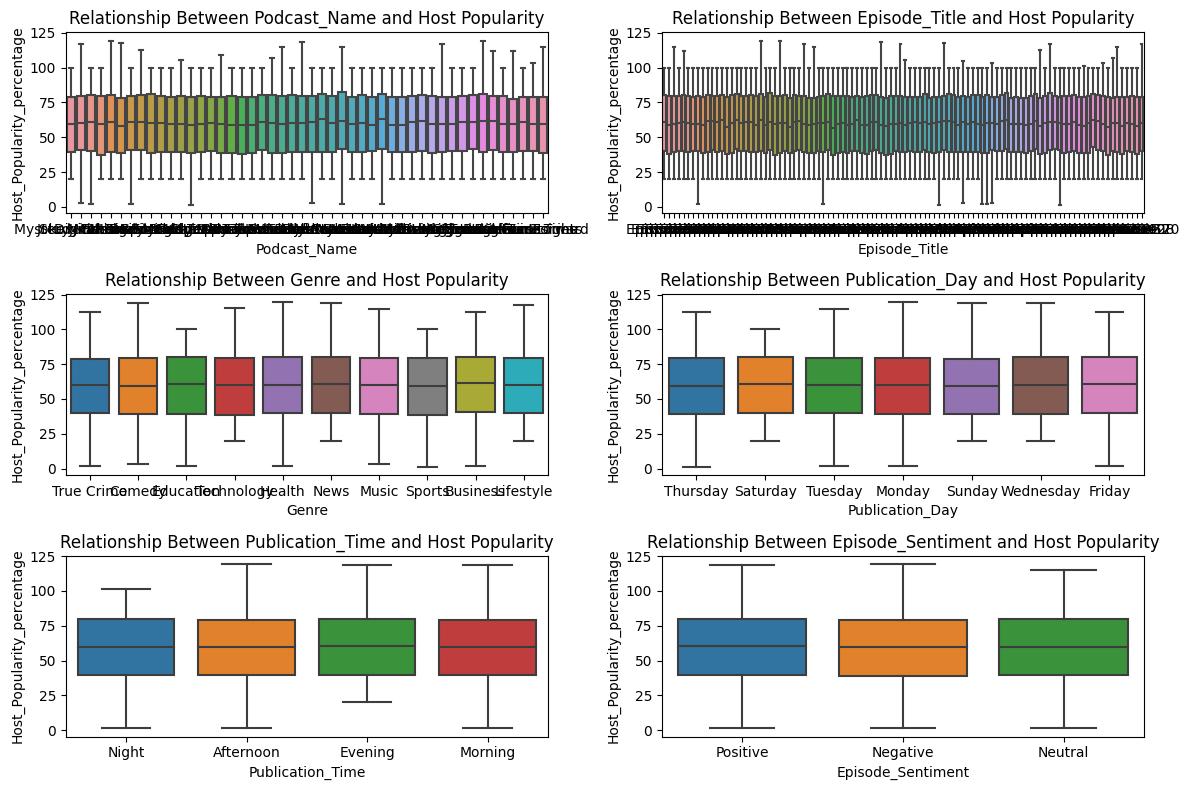

In [16]:
# relationship between cateogircal features and host popularity
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Host_Popularity_percentage"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Host Popularity")

plt.tight_layout()
plt.show()

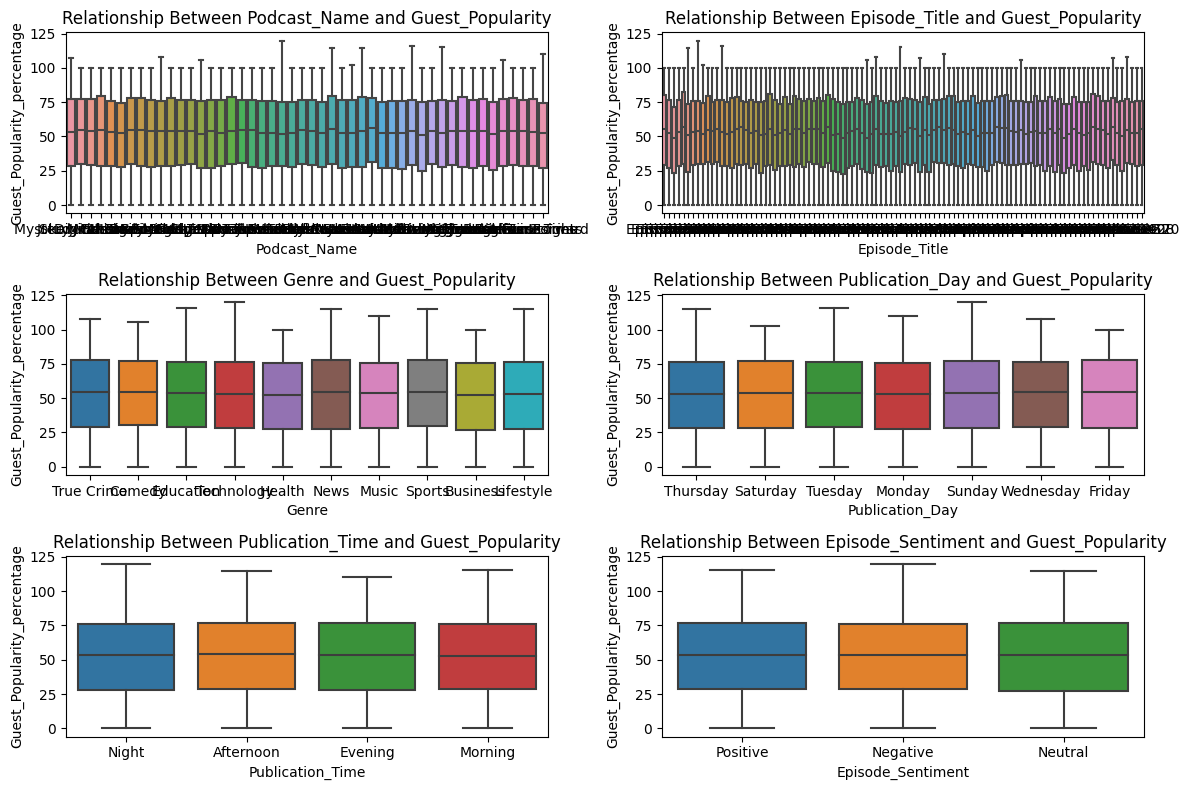

In [17]:
# relationship between cateogircal features and Guest Popularity
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Guest_Popularity_percentage"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Guest_Popularity")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


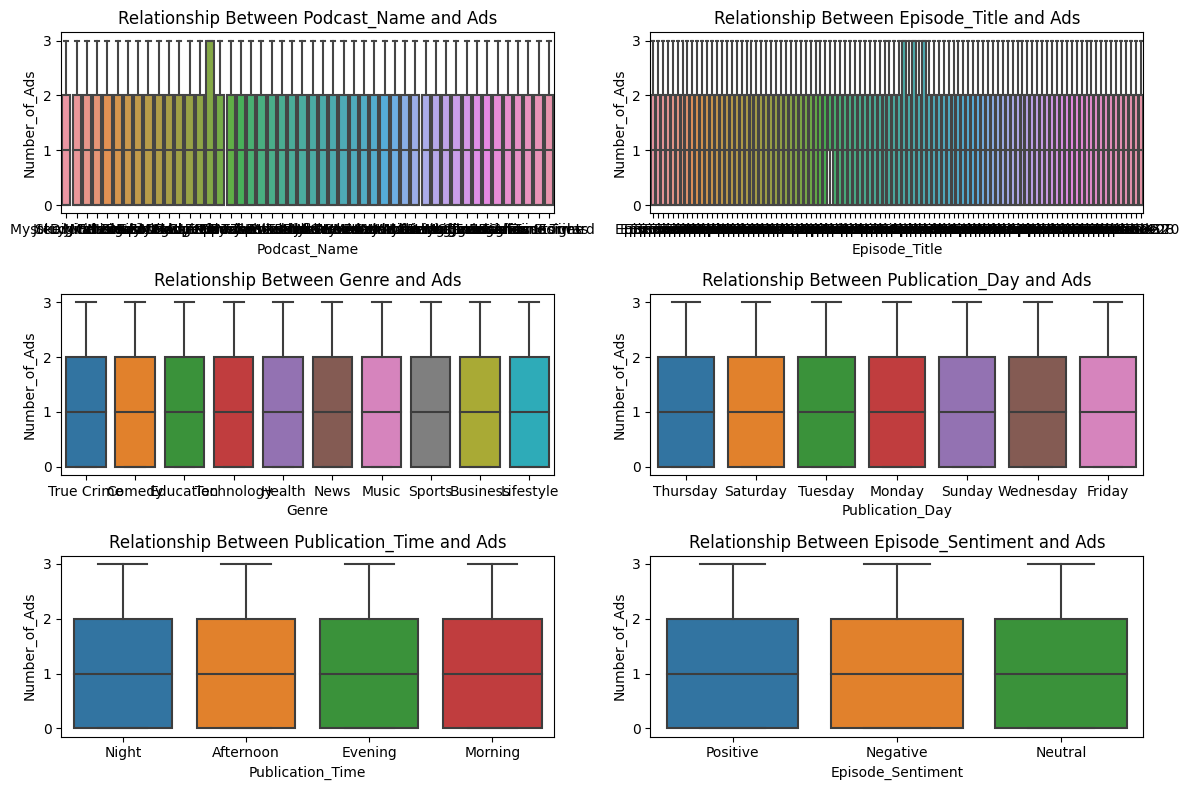

In [18]:
# relationship between cateogircal features and Ads
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df[df["Number_of_Ads"]<10]["Number_of_Ads"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Ads")

plt.tight_layout()
plt.show()

### Findings from Relationships Between Categorical and Numeric Data
- For just about every interaction it seems like the categorical features do not have much to do with the numerical features. This means that the features are largely independent of each other which could be highly benefitial to building a robust model.
- Categorical Features do not have much to do with the outcome feature. This might be problematic as it means that theres not a lot to explain the variation in the outcome variable.

# Data Cleaning
Things to clean up:  
1. What to do about Outliers
2. What to do about missing data

## Handling Outliers
We have 2 variables that have significant outliers in our data. The first one is the number of ads. We will just filter this to podcasts with less than 10 ads. The second variable with outliers is Episode length. There is one podcast with a length over 300 minutes, again since the number of outliers is quite small, we can just drop them.

In [19]:
df_outliers = df[(df["Number_of_Ads"] > 10) | (df["Episode_Length_minutes"] > 300) | (df["Host_Popularity_percentage"] > 100) | (df["Guest_Popularity_percentage"] > 100)]
df_outliers.info()
df_outliers.head()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 6770 to 723350
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Podcast_Name                 54 non-null     object 
 1   Episode_Title                54 non-null     object 
 2   Episode_Length_minutes       48 non-null     float64
 3   Genre                        54 non-null     object 
 4   Host_Popularity_percentage   54 non-null     float64
 5   Publication_Day              54 non-null     object 
 6   Publication_Time             54 non-null     object 
 7   Guest_Popularity_percentage  52 non-null     float64
 8   Number_of_Ads                54 non-null     float64
 9   Episode_Sentiment            54 non-null     object 
 10  Listening_Time_minutes       54 non-null     float64
dtypes: float64(5), object(6)
memory usage: 5.1+ KB


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
6770,Tune Time,Episode 85,NaN,Music,73.54,Wednesday,Night,107.08,0.0,Positive,35.25323
23925,Fitness First,Episode 79,93.17,Health,117.76,Sunday,Morning,67.73,2.0,Positive,81.23646
32435,World Watch,Episode 44,10.94,News,35.98,Thursday,Afternoon,114.72,0.0,Negative,1.62509
79078,Current Affairs,Episode 17,107.24,News,118.73,Sunday,Evening,71.24,1.0,Positive,50.49238
86967,Tune Time,Episode 68,35.62,Music,27.20,Monday,Night,106.90,0.0,Positive,32.97339


In [20]:
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,64.504738,59.859901,52.236449,1.348855,45.437406
std,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,1.300000,0.000000,0.000000,0.000000
25%,35.730000,39.410000,28.380000,0.000000,23.178350
50%,63.840000,60.050000,53.580000,1.000000,43.379460
75%,94.070000,79.530000,76.600000,2.000000,64.811580
max,325.240000,119.460000,119.910000,103.910000,119.970000


In [21]:
df = df[((df["Number_of_Ads"] < 10) | df["Number_of_Ads"].isna()) & 
             ((df["Episode_Length_minutes"] < 300) | df["Episode_Length_minutes"].isna()) & 
             (df["Host_Popularity_percentage"] <= 100) &
             (df["Host_Popularity_percentage"] >= 20) &
             ((df["Guest_Popularity_percentage"] <= 100) | df["Guest_Popularity_percentage"].isna())]
df.describe()

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,662851.000000,749937.000000,603910.000000,749936.000000,749937.000000
mean,64.503523,59.859068,52.234920,1.347938,45.436349
std,32.967924,22.870788,28.449696,1.110975,27.137709
min,0.000000,20.000000,0.000000,0.000000,0.000000
25%,35.730000,39.410000,28.380000,0.000000,23.178350
50%,63.840000,60.050000,53.580000,1.000000,43.379460
75%,94.070000,79.530000,76.600000,2.000000,64.811580
max,120.930000,100.000000,99.990000,3.000000,119.970000


## Analyzing Problems with Missing Data
Variables with Missing Data:
- Episode_Length_minutes
- Guest_Popularity_percentage
- Number_of_Ads

In [22]:
df_missing = df[df.isnull().any(axis=1)]

In [23]:
df_missing.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
5,Fitness First,Episode 19,26.54,Health,48.96,Saturday,Afternoon,NaN,3.0,Positive,22.77047
8,Daily Digest,Episode 32,105.87,News,69.81,Monday,Evening,NaN,2.0,Neutral,68.00124
9,Music Matters,Episode 81,NaN,Music,82.18,Thursday,Night,59.72,3.0,Neutral,45.94761
16,Study Sessions,Episode 82,78.47,Education,48.84,Sunday,Afternoon,NaN,2.0,Neutral,42.89441


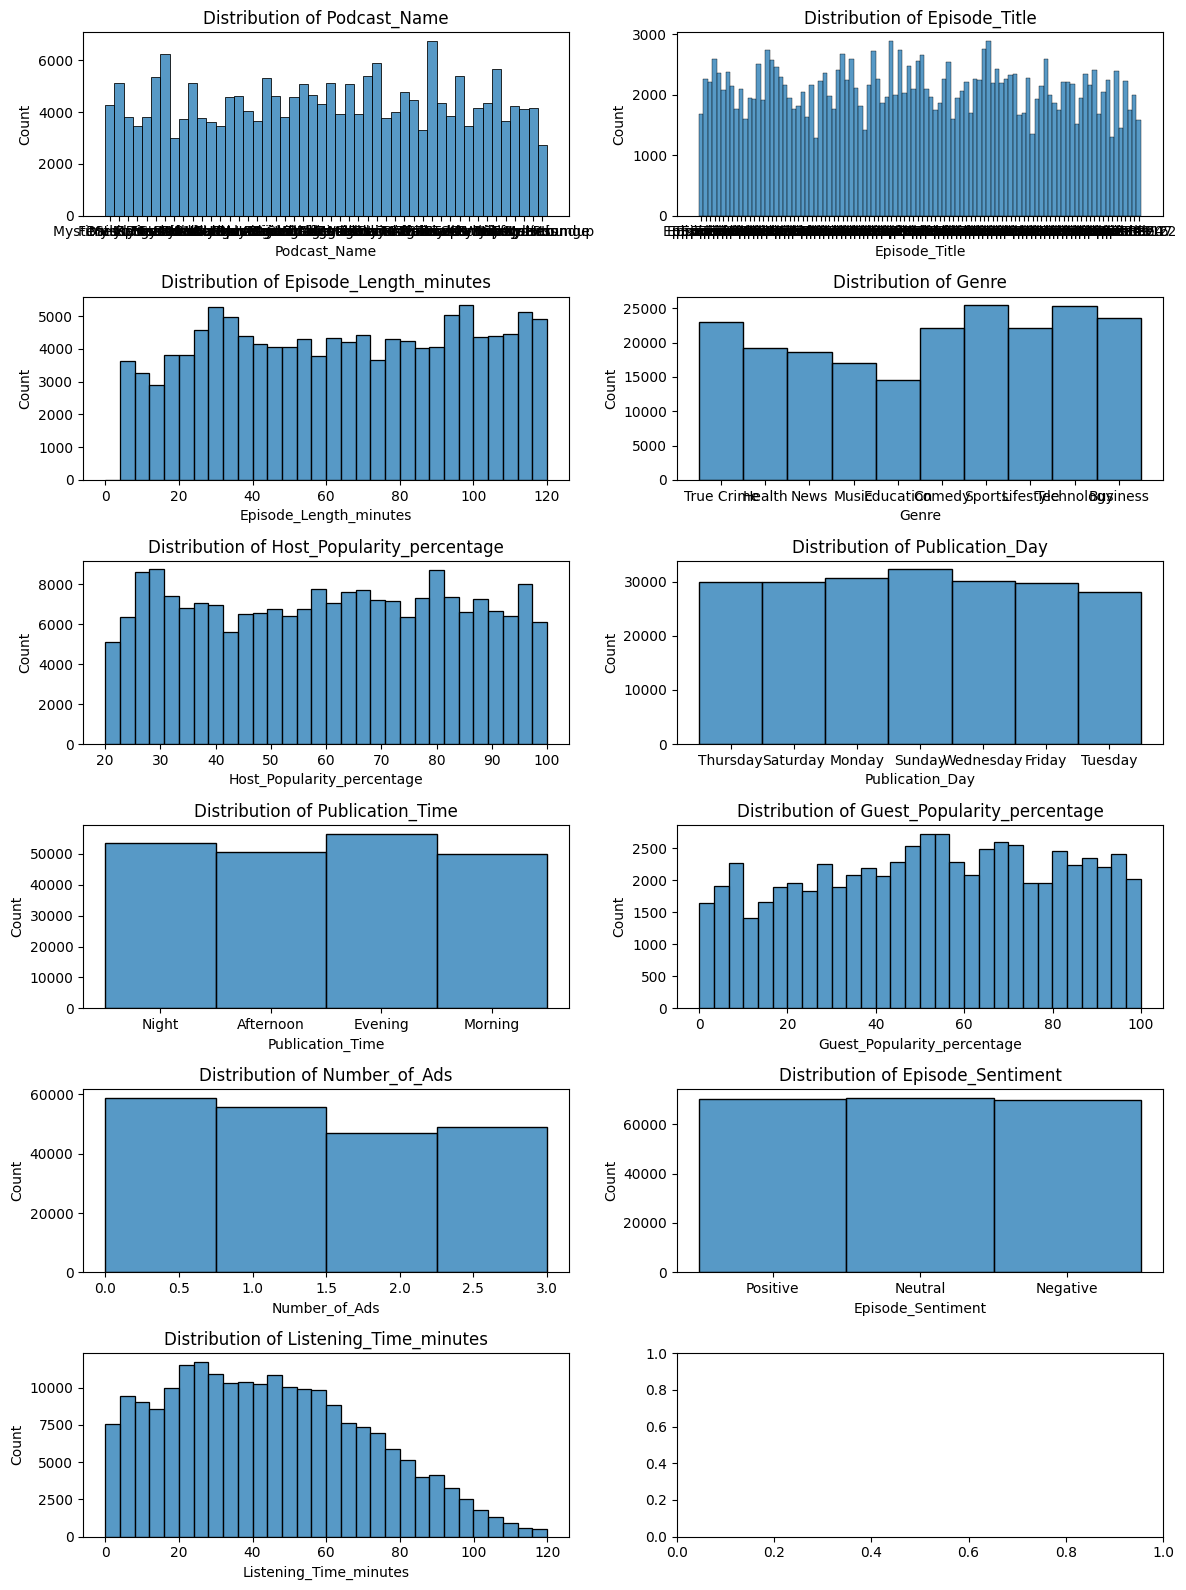

In [24]:
fig, axes = plt.subplots(6, 2, figsize=(12, 16))
axes = axes.flatten()

for i, feature in enumerate(df.columns):
    sns.histplot(df_missing[feature], ax=axes[i], bins=min(30, df[feature].nunique()))
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

## Handling Guest Popularity
I will assume that Guest popularity is more or less uniformly distributed even though there is a very slight skew in the data.

In [25]:
def replace_guest_popularity(df):
    df_temp = df.copy()
    n_missing_guest = df["Guest_Popularity_percentage"].isna().sum()
    replacement_vals = np.random.uniform(0, 100, n_missing_guest)
    df_temp.loc[df_temp["Guest_Popularity_percentage"].isna(), "Guest_Popularity_percentage"] = replacement_vals
    return df_temp

In [26]:
df = replace_guest_popularity(df)

<Axes: xlabel='Guest_Popularity_percentage', ylabel='Count'>

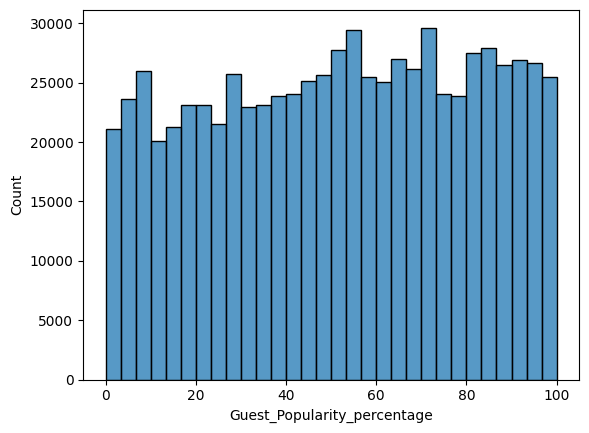

In [27]:
sns.histplot(df["Guest_Popularity_percentage"], bins=30)

### Handling Number of Ads

In [28]:
# i am too lazy to investigate why number of ads has a missing outlier, im just going to encode it as 0
df.loc[df["Number_of_Ads"].isna(), "Number_of_Ads"] = 0

In [29]:
df.isna().sum()

Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         87086
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage        0
Number_of_Ads                      0
Episode_Sentiment                  0
Listening_Time_minutes             0
dtype: int64

## Handling Episode Length Minutes

Just making another encoding for things with missing, 1 if episode length is missing, else its going to be 0.

In [30]:
from scipy import stats

In [31]:
def replace_episode_length(df):
    df_temp = df.copy()

    df_temp["Episode_Length_missing"] = pd.isna(df_temp["Episode_Length_minutes"])
    df_temp.loc[df_temp["Episode_Length_minutes"].isna(), "Episode_Length_minutes"] = 60
    return df_temp

df = replace_episode_length(df)

In [32]:
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,749937.000000,749937.000000,749937.000000,749937.000000,749937.000000
mean,63.980554,59.859068,51.811923,1.347936,45.436349
std,31.028242,22.870788,28.552271,1.110976,27.137709
min,0.000000,20.000000,0.000000,0.000000,0.000000
25%,39.420000,39.410000,27.640000,0.000000,23.178350
50%,60.000000,60.050000,52.920000,1.000000,43.379460
75%,90.310000,79.530000,76.290000,2.000000,64.811580
max,120.930000,100.000000,99.998090,3.000000,119.970000


<Axes: xlabel='Episode_Length_minutes', ylabel='Count'>

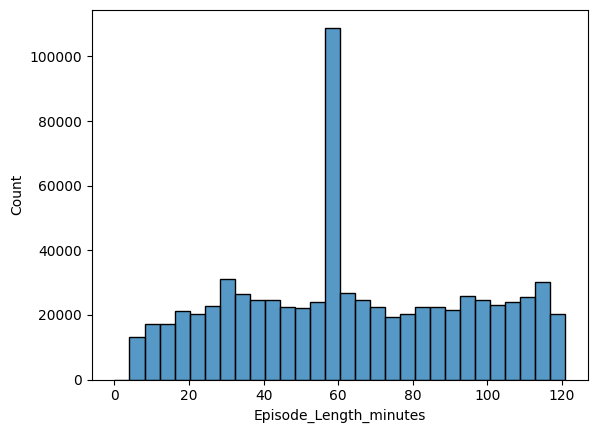

In [33]:
sns.histplot(df["Episode_Length_minutes"], bins=30)

/usr/local/lib/python3.10/dist-packages/seaborn/_stats/counting.py:137: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bin_edges = np.histogram_bin_edges(vals, bins, binrange, weight)
/usr/local/lib/python3.10/dist-packages/seaborn/_stats/counting.py:176: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, edges = np.histogram(vals, **bin_kws, weights=weights, density=density)


<Axes: xlabel='Episode_Length_missing', ylabel='Count'>

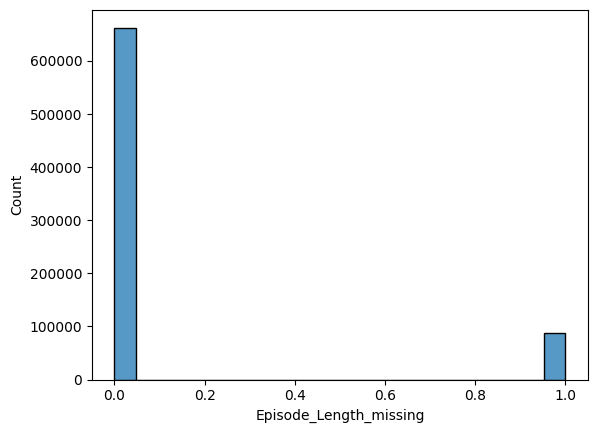

In [34]:
sns.histplot(df["Episode_Length_missing"])

# Further Visualizations

Text(0.5, 1.0, 'Correlation Matrix')

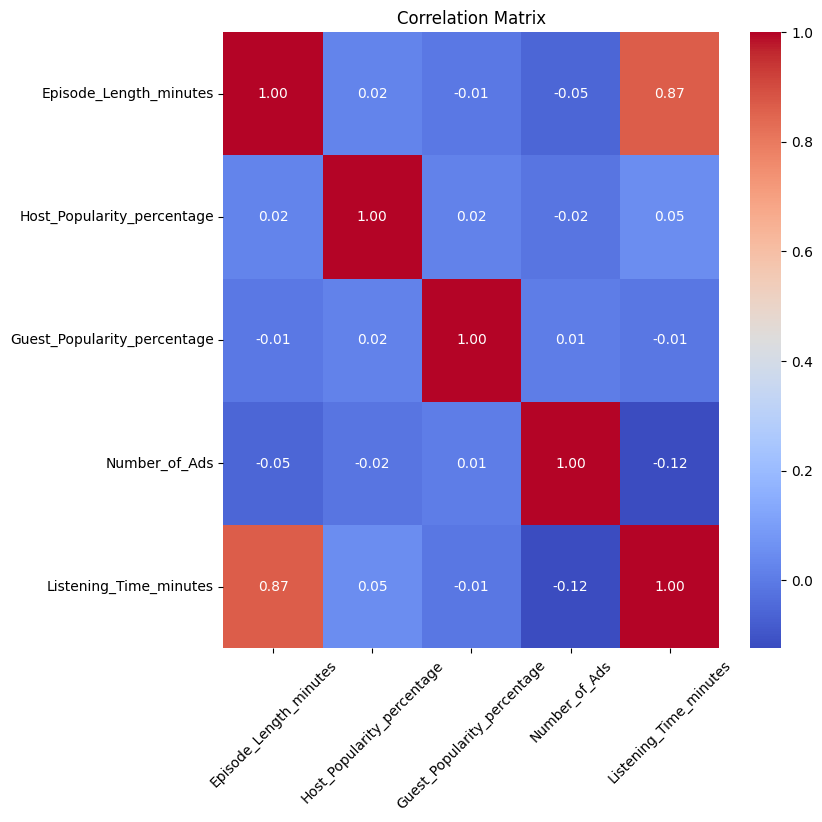

In [35]:
# correlation Matrix
corr_matrix = df[num_vars].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.title("Correlation Matrix")

The correlation between Episode Length and Listening Time dropped Significantly because of our addition of observations sampled without respect to listening time

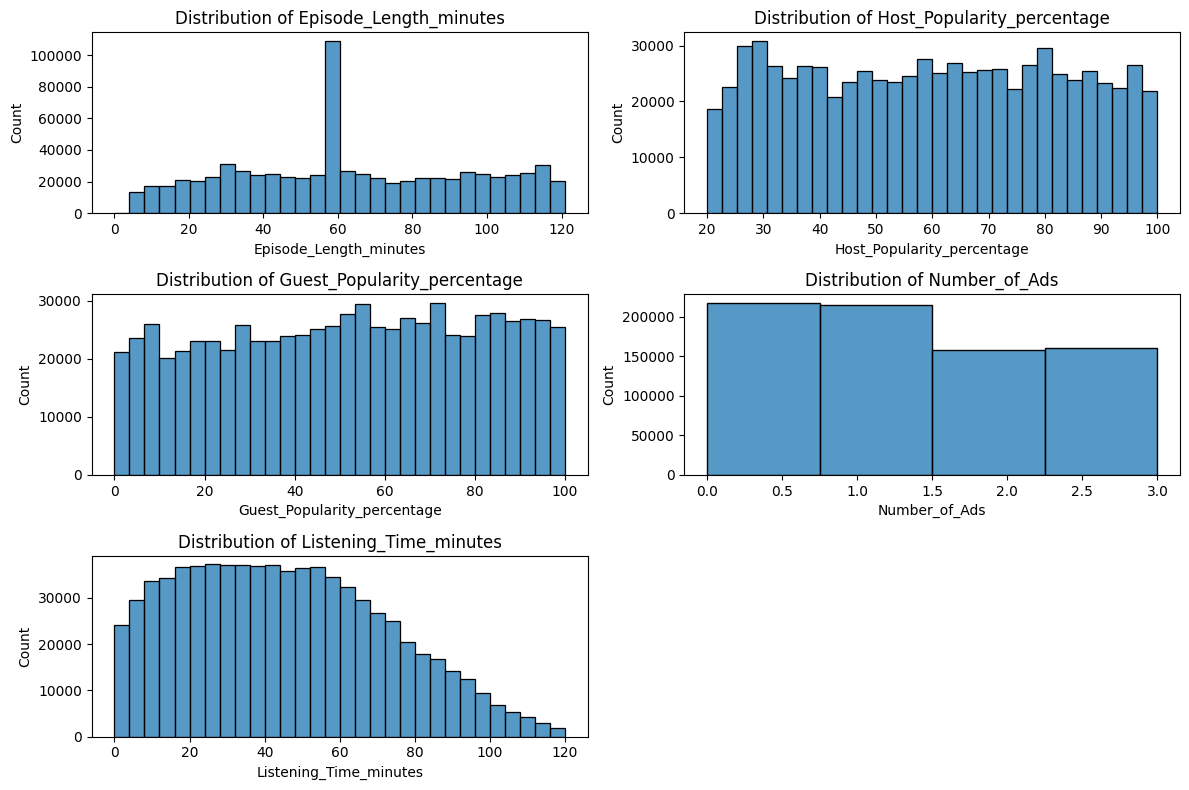

In [36]:
# visualizing new numeric variable distributions
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.histplot(df[feature], bins=min(df[feature].nunique(), 30), ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")

axes[5].remove()
plt.tight_layout()
plt.show()

# Feature Engineering

### Transformations to Apply
#### Variable Specific Transformations
- Turning episode title into discrete numeric variable for the episode number
  
#### Numeric  
- Standardization
- Box-Cox Transformation for every numeric variable for funsies
  
#### Categorical  
- One hot encodings
  
#### Numeric and Categorical  
- Interaction Terms Between Every single variable, just for funsies

In [37]:
num_features = ["Episode_Length_minutes", "Host_Popularity_percentage", "Guest_Popularity_percentage", 
                "Number_of_Ads"] # Removed Outcome var

# numerical features actually transformed
num_features_transform = ["Episode_Length_minutes", "Host_Popularity_percentage", "Guest_Popularity_percentage"]

cat_features = ["Podcast_Name", "Genre", "Publication_Day", "Publication_Time", 
                "Episode_Sentiment"] # Episode Title removed since its now int

# This thing not used
features = ["Episode_Length_minutes", "Host_Popularity_percentage", "Guest_Popularity_percentage", 
            "Number_of_Ads", "episode_number", "Podcast_Name", "Genre", "Publication_Day", 
            "Publication_Time", "Episode_Sentiment", "Episode_Length_missing"]

In [38]:
from sklearn.preprocessing import StandardScaler

def make_cool_features(df):
    df_temp = df.copy()

    # encoding episode_title as numerical feature
    
    # Apply the function to create the new column
    df_temp['episode_number'] = df_temp['Episode_Title'].str.extract(r'Episode (\d+)').astype(int)
    df_temp = df_temp.drop(columns=["Episode_Title"])
    
    # encoding categorical features
    df_temp = pd.get_dummies(df_temp, columns=cat_features)

    # standardizationfor numerical features
    scaler = StandardScaler()
    df_temp[num_features_transform] = scaler.fit_transform(df_temp[num_features_transform])

    # log transformations
    for feature in num_features_transform:
        if (df_temp[feature] <= 0).any():
            shift_value = abs(df_temp[feature].min()) + 1
            df_temp[f'{feature}_log'] = np.log(df_temp[feature] + shift_value)
        else:
            df_temp[f'{feature}_log'] = np.log(df_temp[feature])
    
    return df_temp

In [39]:
df_cool = make_cool_features(df)
df_cool.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,Episode_Length_missing,episode_number,Podcast_Name_Athlete's Arena,Podcast_Name_Brain Boost,Podcast_Name_Business Briefs,...,Publication_Time_Afternoon,Publication_Time_Evening,Publication_Time_Morning,Publication_Time_Night,Episode_Sentiment_Negative,Episode_Sentiment_Neutral,Episode_Sentiment_Positive,Episode_Length_minutes_log,Host_Popularity_percentage_log,Guest_Popularity_percentage_log
0,-0.128288,0.653713,0.336592,0.0,31.41998,True,98,False,False,False,...,False,False,False,True,False,False,True,1.076272,1.222748,1.147792
1,1.798990,0.310043,0.845400,2.0,88.01241,False,26,False,False,False,...,True,False,False,False,True,False,False,1.581244,1.116072,1.297473
2,0.319691,0.442090,-1.500474,0.0,44.92531,False,16,False,False,False,...,False,True,False,False,True,False,False,1.218379,1.158416,0.273198
3,0.102792,-0.115390,0.941715,2.0,46.27824,False,45,False,False,False,...,False,False,True,False,False,False,True,1.152091,0.965996,1.323448
4,1.499585,0.883701,0.240544,3.0,75.61031,False,86,False,False,False,...,True,False,False,False,False,True,False,1.517673,1.288267,1.116838


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
# Spliting Data
df_baseline = pd.get_dummies(df)
X_baseline = df_baseline.drop(columns=["Listening_Time_minutes"])
y_baseline = df_baseline["Listening_Time_minutes"]

X_train_baseline, X_val_baseline, y_train_baseline, y_val_baseline = train_test_split(X_baseline, y_baseline, test_size = 0.3, random_state = 16)

In [42]:
# Split for fancier regression
X_cool = df_cool.drop(columns=["Listening_Time_minutes"])
y_cool = df_cool["Listening_Time_minutes"]

X_train_cool, X_val_cool, y_train_cool, y_val_cool = train_test_split(X_cool, y_cool, test_size = 0.3, random_state = 16)

In [43]:
df_cool.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,Episode_Length_missing,episode_number,Podcast_Name_Athlete's Arena,Podcast_Name_Brain Boost,Podcast_Name_Business Briefs,...,Publication_Time_Afternoon,Publication_Time_Evening,Publication_Time_Morning,Publication_Time_Night,Episode_Sentiment_Negative,Episode_Sentiment_Neutral,Episode_Sentiment_Positive,Episode_Length_minutes_log,Host_Popularity_percentage_log,Guest_Popularity_percentage_log
0,-0.128288,0.653713,0.336592,0.0,31.41998,True,98,False,False,False,...,False,False,False,True,False,False,True,1.076272,1.222748,1.147792
1,1.798990,0.310043,0.845400,2.0,88.01241,False,26,False,False,False,...,True,False,False,False,True,False,False,1.581244,1.116072,1.297473
2,0.319691,0.442090,-1.500474,0.0,44.92531,False,16,False,False,False,...,False,True,False,False,True,False,False,1.218379,1.158416,0.273198
3,0.102792,-0.115390,0.941715,2.0,46.27824,False,45,False,False,False,...,False,False,True,False,False,False,True,1.152091,0.965996,1.323448
4,1.499585,0.883701,0.240544,3.0,75.61031,False,86,False,False,False,...,True,False,False,False,False,True,False,1.517673,1.288267,1.116838


# Model Building

## Baseline Linear Regression Model

In [44]:
# imports
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [45]:
def rmse(y_pred, y_actual):
    # idk why the import from sklearn isn't working
    return np.sqrt(mean_squared_error(y_pred, y_actual))

In [46]:
lr_baseline = LinearRegression().fit(X_train_baseline, y_train_baseline)

baseline_pred = lr_baseline.predict(X_val_baseline)
baseline_score = rmse(baseline_pred, y_val_baseline)
print(f"Baseline RMSE: {baseline_score}")

Baseline RMSE: 13.350573047221669


## Fancier Linear Regression Model

In [47]:
lr_cool = LinearRegression().fit(X_train_cool, y_train_cool)

cool_pred = lr_cool.predict(X_val_cool)
cool_score = rmse(cool_pred, y_val_cool)
print(f"Baseline RMSE: {cool_score}")

Baseline RMSE: 13.342585421094661


wowie a tiny improvement!

In [48]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1, max_iter=10000, tol=0.0001)
lasso_model.fit(X_train_cool, y_train_cool)

cool_pred = lasso_model.predict(X_val_cool)
cool_score = rmse(cool_pred, y_val_cool)
print(f"Baseline RMSE: {cool_score}")

Baseline RMSE: 13.372478565178941


In [49]:
cool_pred = lasso_model.predict(X_val_cool)
cool_score = rmse(cool_pred, y_val_cool)
print(f"Baseline RMSE: {cool_score}")

Baseline RMSE: 13.372478565178941


In [50]:
feature_importance = pd.DataFrame({
    'Feature': X_train_cool.columns,
    'Coefficient': lasso_model.coef_
})
selected_features = feature_importance[feature_importance['Coefficient'] != 0]['Feature'].tolist()

print(selected_features)
print(len(selected_features))

['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 'episode_number', 'Episode_Sentiment_Positive']
6


# Submission

In [51]:
df_test = pd.read_csv("/kaggle/input/playground-series-s5e4/test.csv")
df_test.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [52]:
df_test.isna().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

In [53]:
# data cleaning for test set
def replace_episode_length(df):
    df_temp = df.copy()

    df_temp["Episode_Length_missing"] = pd.isna(df_temp["Episode_Length_minutes"])
    df_temp.loc[df_temp["Episode_Length_minutes"].isna(), "Episode_Length_minutes"] = 60 # arbitrarily set it to mean
    return df_temp

def replace_outliers(df):
    df_temp = df.copy()

    df_temp.loc[df_temp["Episode_Length_minutes"] > 300, "Episode_Length_minutes"] = 120
    df_temp.loc[df_temp["Number_of_Ads"] > 10, "Number_of_Ads"] = 10
    df_temp.loc[df_temp["Host_Popularity_percentage"] < 20] = 20
    df_temp.loc[df_temp["Host_Popularity_percentage"] > 100] = 100
    df_temp.loc[df_temp["Guest_Popularity_percentage"] > 100] = 100
    
    return df_temp

def clean_test_set(df):
    df_temp = df.copy()
    df_temp = df_temp.drop(columns=["id"])

    # replacing outliers with max/min
    df_temp = replace_outliers(df_temp)
    
    # replace guest Popularity percentage with normal uniform distribution stuff
    df_temp = replace_guest_popularity(df_temp)
    
    # replace Episode_Length_minute with linear regression prediction for missing stuff
    df_temp = replace_episode_length(df_temp)

    df_temp["Episode_Title"] = df_temp.apply(lambda x: x["Episode_Title"] if not str(x["Episode_Title"]).isdigit() else "Episode " + str(x["Episode_Title"]), axis=1)
    
    return df_temp

In [54]:
X = df_cool.drop(columns=["Listening_Time_minutes"])
y = df_cool["Listening_Time_minutes"]

lasso_model = Lasso(alpha=0.1, max_iter=10000, tol=0.0001)
lasso_model.fit(X, y)

cool_pred = lasso_model.predict(X)
cool_score = rmse(cool_pred, y)
print(f"Training RMSE: {cool_score}")

Training RMSE: 13.348138582809268


In [55]:
df_test.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [56]:
df_test_clean = clean_test_set(df_test)
df_test_cool = make_cool_features(df_test_clean)

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [57]:
X_cool.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Episode_Length_missing,episode_number,Podcast_Name_Athlete's Arena,Podcast_Name_Brain Boost,Podcast_Name_Business Briefs,Podcast_Name_Business Insights,...,Publication_Time_Afternoon,Publication_Time_Evening,Publication_Time_Morning,Publication_Time_Night,Episode_Sentiment_Negative,Episode_Sentiment_Neutral,Episode_Sentiment_Positive,Episode_Length_minutes_log,Host_Popularity_percentage_log,Guest_Popularity_percentage_log
0,-0.128288,0.653713,0.336592,0.0,True,98,False,False,False,False,...,False,False,False,True,False,False,True,1.076272,1.222748,1.147792
1,1.798990,0.310043,0.845400,2.0,False,26,False,False,False,False,...,True,False,False,False,True,False,False,1.581244,1.116072,1.297473
2,0.319691,0.442090,-1.500474,0.0,False,16,False,False,False,False,...,False,True,False,False,True,False,False,1.218379,1.158416,0.273198
3,0.102792,-0.115390,0.941715,2.0,False,45,False,False,False,False,...,False,False,True,False,False,False,True,1.152091,0.965996,1.323448
4,1.499585,0.883701,0.240544,3.0,False,86,False,False,False,False,...,True,False,False,False,False,True,False,1.517673,1.288267,1.116838


In [58]:
df_test_cool.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Episode_Length_missing,episode_number,Podcast_Name_20,Podcast_Name_100,Podcast_Name_Athlete's Arena,Podcast_Name_Brain Boost,...,Publication_Time_Morning,Publication_Time_Night,Episode_Sentiment_20,Episode_Sentiment_100,Episode_Sentiment_Negative,Episode_Sentiment_Neutral,Episode_Sentiment_Positive,Episode_Length_minutes_log,Host_Popularity_percentage_log,Guest_Popularity_percentage_log
0,0.481178,-0.944372,0.053697,1.0,False,73,False,False,False,False,...,False,False,False,False,False,True,False,1.242589,0.583076,1.053711
1,-1.164985,0.505839,0.125807,0.0,False,23,False,False,False,False,...,True,False,False,False,False,True,False,0.597962,1.176114,1.078540
2,0.163481,0.357234,1.601426,0.0,False,11,False,False,False,False,...,False,False,False,False,False,False,True,1.146410,1.129189,1.485235
3,1.654984,-1.587308,-0.001654,2.0,False,73,False,False,False,False,...,True,False,False,False,False,False,True,1.534365,0.138548,1.034224
4,0.267232,-0.070662,-1.418712,2.0,False,50,False,False,False,False,...,True,False,False,False,False,True,False,1.178848,0.980299,0.333515


In [59]:
# not epic observations
df_not_cool = df_test_clean[(df_test_clean["Podcast_Name"] == 20) | (df_test_clean["Podcast_Name"] == 100)]
df_not_cool

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Episode_Length_missing
986,20,Episode 20,20.0,20,20.0,20,20,20.0,20.0,20,False
59446,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
64298,20,Episode 20,20.0,20,20.0,20,20,20.0,20.0,20,False
70250,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
78898,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
88169,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
90886,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
106857,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
108106,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False
121878,100,Episode 100,100.0,100,100.0,100,100,100.0,100.0,100,False


In [60]:
# special way to encode this
class CustomLinearRegression():
    def __init__(self):
        self.model = Lasso(alpha = 0.01)
    
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
    
    def predict(self, X):
        # Make normal predictions
        predictions = self.model.predict(X)
        
        # Check for special case rows (all values either 20 or 100)
        for i, row in enumerate(X.values):
            if all(val in [20, 100] for val in row):
                # Apply your rule here
                if row["Podcast_Name"] == 100:
                    predictions[i] = 100
                else:
                    predictions[i] = 20
                    
        return predictions

lasso_model = CustomLinearRegression()
lasso_model.fit(X, y)

cool_pred = lasso_model.predict(X)
cool_score = rmse(cool_pred, y)
print(f"Training RMSE: {cool_score}")

Training RMSE: 13.321017325140073


In [61]:
cols_to_drop = [col for col in df_test_cool.columns if '20' in col or '100' in col]
df_test_cool = df_test_cool.drop(columns=cols_to_drop)

In [62]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e4/sample_submission.csv")
submission["Listening_Time_minutes"] = lasso_model.predict(df_test_cool)

In [63]:
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Listening_Time_minutes
0,750000,55.695028
1,750001,20.164888
2,750002,51.673001
3,750003,82.946400
4,750004,49.654751
